In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Input
import os

In [2]:
print(tf.config.list_physical_devices('GPU'))
print(len(tf.config.list_physical_devices('GPU')))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1


In [3]:
# Set dataset path
data_dir = r'D:\Project\data_kaggle\aug\train_split'

In [4]:
batch_size = 32
img_height = 224
img_width = 224
image_size = (img_height, img_width)
epochs = int(input("Enter epochs number: "))

Enter epochs number:  10


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb'  # Force RGB mode
)

Found 5863 images belonging to 8 classes.


In [6]:
val_datagen = ImageDataGenerator(
    rescale=1./255
)

val_data = r"D:\Project\data_kaggle\aug\val_split"

val_generator = val_datagen.flow_from_directory(
    val_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

Found 1469 images belonging to 8 classes.


In [7]:
model = Sequential([
    Input(shape=(224, 224, 3)),  # Original AlexNet used 227x227 images

    Conv2D(96, (11, 11), strides=4, activation='relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),
    BatchNormalization(),

    Conv2D(256, (5, 5), padding="same", activation='relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),
    BatchNormalization(),

    Conv2D(384, (3, 3), padding="same", activation='relu'),
    Conv2D(384, (3, 3), padding="same", activation='relu'),
    Conv2D(256, (3, 3), padding="same", activation='relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 54, 54, 96)        34944     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 26, 26, 96)        0         
_________________________________________________________________
batch_normalization (BatchNo (None, 26, 26, 96)        384       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 26, 26, 256)       614656    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 12, 12, 256)       0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 12, 12, 256)       1024      
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 12, 12, 384)       8

In [9]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
# Train the model
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

Epoch 1/10
184/184 [==============================] - 60s 255ms/step - loss: 2.2692 - accuracy: 0.1922 - val_loss: 2.0407 - val_accuracy: 0.1947
Epoch 2/10
184/184 [==============================] - 47s 254ms/step - loss: 2.0396 - accuracy: 0.1948 - val_loss: 2.0418 - val_accuracy: 0.1947
Epoch 3/10
184/184 [==============================] - 46s 252ms/step - loss: 2.0415 - accuracy: 0.1922 - val_loss: 2.0377 - val_accuracy: 0.1947
Epoch 4/10
184/184 [==============================] - 48s 260ms/step - loss: 2.0402 - accuracy: 0.1948 - val_loss: 2.0390 - val_accuracy: 0.1947
Epoch 5/10
184/184 [==============================] - 47s 253ms/step - loss: 2.0404 - accuracy: 0.1948 - val_loss: 2.0378 - val_accuracy: 0.1947
Epoch 6/10
184/184 [==============================] - 47s 253ms/step - loss: 2.0392 - accuracy: 0.1948 - val_loss: 2.0378 - val_accuracy: 0.1947
Epoch 7/10
184/184 [==============================] - 46s 249ms/step - loss: 2.0395 - accuracy: 0.1948 - val_loss: 2.0377 - val_ac

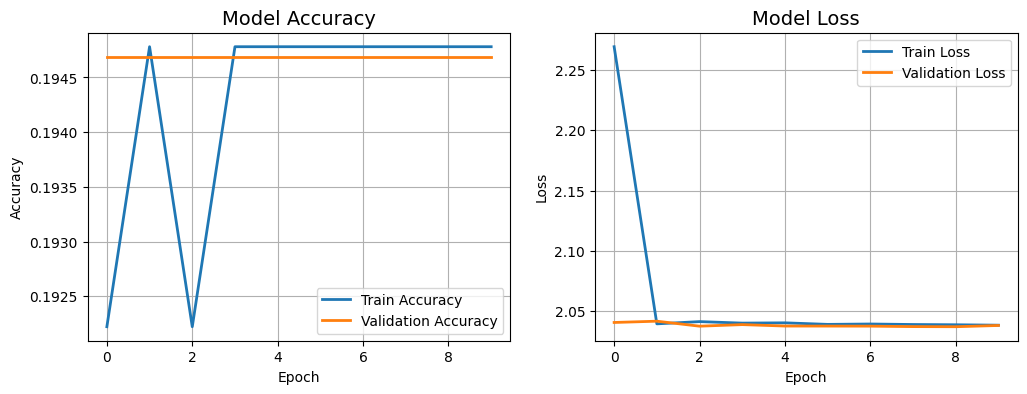

In [11]:
# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [12]:
# Evaluate model
test_data = r'D:\Project\data_kaggle\test'

eval_generator = train_datagen.flow_from_directory(
    test_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

y_true = eval_generator.classes
y_pred = model.predict(eval_generator)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)  # Fix tf.argmax issue

Found 190 images belonging to 8 classes.


In [13]:
# Print classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes))

# Plot confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
class_labels = list(train_generator.class_indices.keys())


Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.00      0.00      0.00        21
           2       0.00      0.00      0.00        25
           3       0.00      0.00      0.00        23
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00        23
           6       0.14      1.00      0.24        26
           7       0.00      0.00      0.00        23

    accuracy                           0.14       190
   macro avg       0.02      0.12      0.03       190
weighted avg       0.02      0.14      0.03       190



C:\Users\mohan\anaconda3\envs\gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mohan\anaconda3\envs\gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mohan\anaconda3\envs\gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


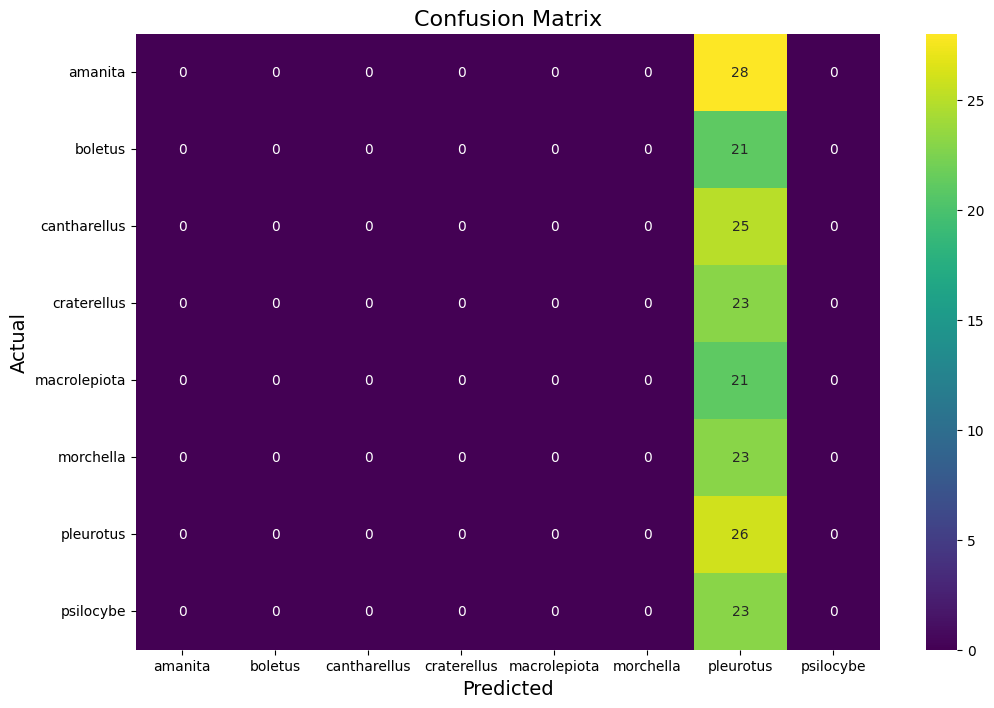

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="viridis", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

In [15]:
model_version = epochs
next_version = str(int(model_version) + 10)

In [16]:
import shutil

notebook_filename = f"CNN_{model_version}_ADAM.ipynb"
new_notebook_filename = f"CNN_{next_version}_ADAM.ipynb"

shutil.copy(notebook_filename, new_notebook_filename)
print(f"Notebook copied as {new_notebook_filename}")

Notebook copied as CNN_20_ADAM.ipynb


In [ ]:
os._exit(00)